In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
sns.set_theme() # set default Seaborn theme
df = pd.read_csv('../task-data/q1_visualizing_data/vocabulary_dataset.csv')

I'd like to first get an overview of the dataset.

In [3]:
df.head() # first 5 items

,targetWord,age_group,pc,num_subjects
0,acorn,3,1.000000,3
1,acorn,4,0.800000,5
2,acorn,5,1.000000,3
3,acorn,6,1.000000,1
4,acorn,7,0.866667,15


In [4]:
df['targetWord'].nunique() # number of unique words in the dataset

112

In [5]:
df['targetWord'].value_counts() # how many instances of each word across age groups

targetWord
acorn        10
aloe         10
ant          10
antenna      10
artichoke    10
             ..
pistachio     9
prune         9
ship          9
telescope     9
scrabble      1
Name: count, Length: 112, dtype: int64

In [6]:
df['word_length'] = df['targetWord'].str.len() # record the length of each word in the dataframe

# 1A. Useful Plots

Plots of interest:
- average pc by age group
- average pc by word length
- bargraph of pc for bottom 5 and top 5 words averaged across all age groups
- BONUS: average pc by word category

<Axes: xlabel='age_group', ylabel='average_pc'>

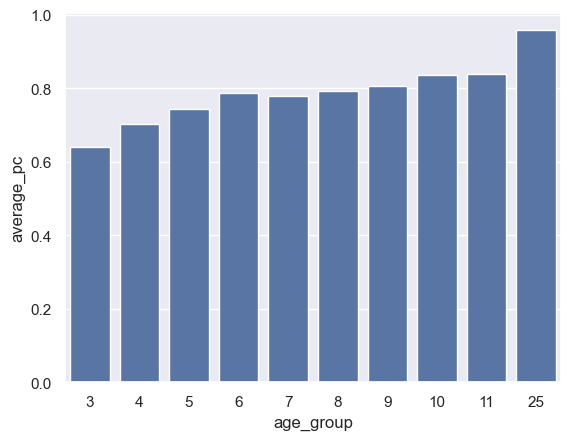

In [ ]:
average_pc_by_age_group = df.groupby('age_group')['pc'].mean().to_frame(name='average_pc').reset_index()

sns.barplot(average_pc_by_age_group, x='age_group', y='average_pc', )

In [8]:
children_only_df = df[df['age_group'] != 25] # remove samples for 25 year-olds

In [9]:
child_average_pc_by_word_length = children_only_df.groupby(children_only_df['targetWord'].str.len())['pc'].mean().reset_index()
child_average_pc_by_word_length.columns = ['target_word_length', 'average_pc']
child_average_pc_by_word_length

,target_word_length,average_pc
0,3,0.890592
1,4,0.826946
2,5,0.743178
3,6,0.785780
4,7,0.687366
5,8,0.831242
6,9,0.782829
7,10,0.723406
8,11,0.533287


[Text(0.5, 1.0, 'Average percentage correct by word length (children only)')]

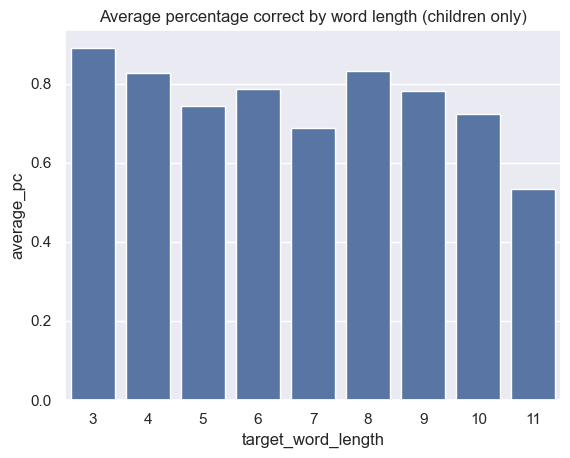

In [10]:
sns.barplot(child_average_pc_by_word_length, x='target_word_length', y='average_pc').set(title='Average percentage correct by word length (children only)')

In [11]:
average_pc_by_word_length = df.groupby(df['targetWord'].str.len())['pc'].mean().reset_index()
average_pc_by_word_length.columns = ['target_word_length', 'average_pc']

In [12]:
average_pc_by_word_length

,target_word_length,average_pc
0,3,0.899641
1,4,0.841736
2,5,0.760878
3,6,0.804297
4,7,0.713819
5,8,0.847734
6,9,0.801565
7,10,0.747702
8,11,0.563155


<Axes: xlabel='target_word_length', ylabel='average_pc'>

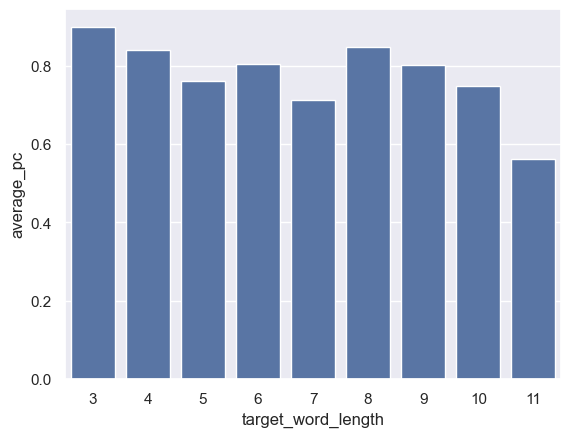

In [13]:
sns.barplot(average_pc_by_word_length, x='target_word_length', y='average_pc')

## Average Percentage Correct for Top and Bottom 5 Words (Children Only)

In [14]:
average_pc_by_word = children_only_df.groupby('targetWord')['pc'].mean().sort_values().reset_index(name='average_pc')

<Axes: xlabel='targetWord', ylabel='average_pc'>

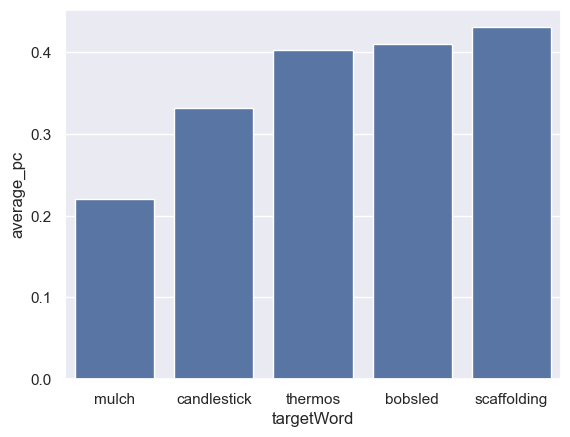

In [15]:
sns.barplot(average_pc_by_word.head(), y='average_pc', x='targetWord')

(0.9, 1.0)

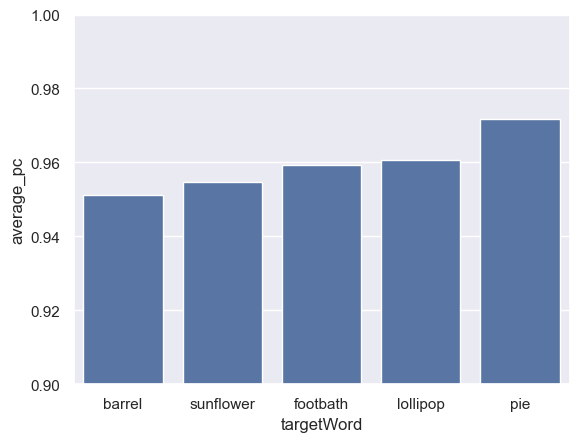

In [16]:
average_pc_word_plot = sns.barplot(average_pc_by_word.tail(), y='average_pc', x='targetWord')
average_pc_word_plot.set_ylim(0.9, 1)

## Highest Variance Words

I'll use the pandas groupby method to create groups of the data for each target word. Then I can calculate the variance across age groups within each of those word groups.


In [17]:
df.groupby('targetWord').get_group('acorn') # visualize the 'acorn' group.

,targetWord,age_group,pc,num_subjects,word_length
0,acorn,3,1.000000,3,5
1,acorn,4,0.800000,5,5
2,acorn,5,1.000000,3,5
3,acorn,6,1.000000,1,5
4,acorn,7,0.866667,15,5
5,acorn,8,0.947368,38,5
6,acorn,9,0.963636,55,5
7,acorn,10,0.931818,44,5
8,acorn,11,1.000000,18,5
9,acorn,25,0.986111,72,5


Notice the number of sampled subjects also varies significantly across age groups. This is worth keeping in mind since we expect higher-sample groups to be more representative of the population and could therefore "count" more in estimating the population variance. However, we'll focus on a simple analysis of the dataset.

In [18]:
pc_variance = df.groupby('targetWord').var()['pc'] # calculate the 'percentage-correct' variance across age groups for each word

In [19]:
pc_variance

targetWord
acorn         0.004586
aloe          0.102023
ant           0.002389
antenna       0.037744
artichoke     0.015549
                ...   
turtle        0.009741
tuxedo        0.021346
typewriter    0.022763
watermelon    0.023495
waterwheel    0.097500
Name: pc, Length: 112, dtype: float64

In [20]:
top_ten_variances: pd.Series = pc_variance.sort_values(ascending=False)[:10] # collect the 10 words with highest variance across age groups

### Which items show the most variance across age?

[Text(0, 0.5, 'target word'), Text(0.5, 0, 'variance across age groups')]

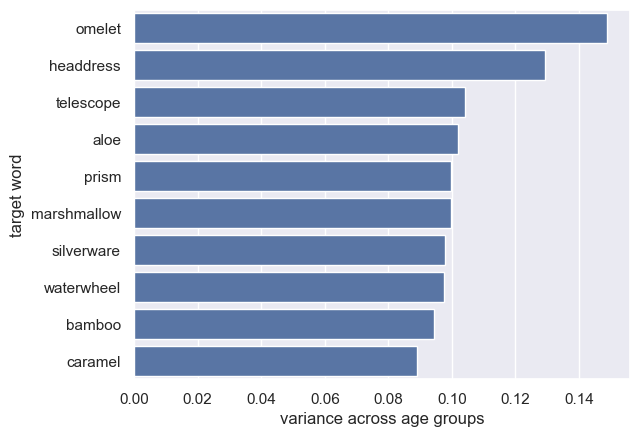

In [21]:
sns.barplot(data=top_ten_variances.to_frame().reset_index(), x='pc', y='targetWord').set(ylabel='target word', xlabel='variance across age groups')

In [22]:
top_ten_var_words: list = top_ten_variances.index.to_list()

In [23]:
top_ten_var_words

['omelet',
 'headdress',
 'telescope',
 'aloe',
 'prism',
 'marshmallow',
 'silverware',
 'waterwheel',
 'bamboo',
 'caramel']

For the plot, I'll focus on the subset of 5 items that show the most variance across age

In [24]:
top_ten_var_words_df = df[df['targetWord'].isin(top_ten_var_words[:5])]

For the individual word across age group plot, I'm interested in seeing how the percentage-correct trends as age increases. I'd like to get a gist for how these trends compare for different words. I'll include markers to identify the data points within the overall trends.

[Text(0.5, 1.0, 'proportion of correct responses by the age of participant'),
 Text(0, 0.5, 'proportion correct')]

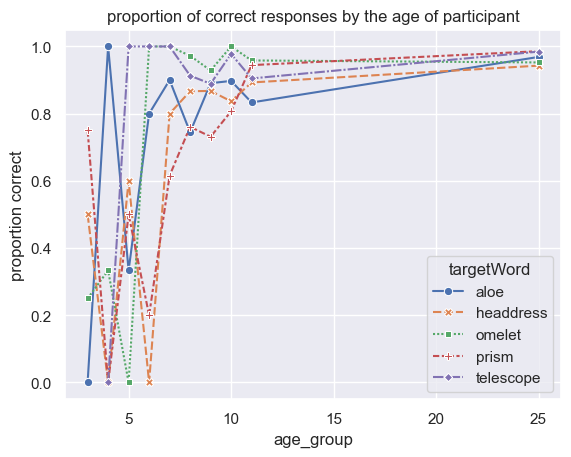

In [29]:
ax = sns.lineplot(data=top_ten_var_words_df, x='age_group', y='pc', hue='targetWord', style='targetWord', markers=True)
ax.set(title='proportion of correct responses by the age of participant', ylabel='proportion correct')